In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset - correct path
df = pd.read_csv('/kaggle/input/datasets/arpitarathwa/geetha-typing-speed-dataset/typing_speed_train.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()
        

Shape: (999, 6)

First 5 rows:


,date,days_ago,wpm,acc,rawWpm,consistency
0,2023-01-15,999,76.89,100.00,76.89,64.65
1,2023-01-16,998,81.67,100.00,81.67,79.00
2,2023-01-17,997,66.03,95.08,66.03,65.34
3,2023-01-18,996,93.18,100.00,93.18,75.54
4,2023-01-19,995,94.22,97.92,94.22,65.40


In [2]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Data types:
date            object
days_ago         int64
wpm            float64
acc            float64
rawWpm         float64
consistency    float64
dtype: object

Missing values:
date           0
days_ago       0
wpm            0
acc            0
rawWpm         0
consistency    0
dtype: int64

Basic statistics:


,days_ago,wpm,acc,rawWpm,consistency
count,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.000000,85.748058,96.192032,89.908298,67.370070
std,288.530761,17.857199,4.044028,19.673983,12.349825
min,1.000000,23.440000,76.190000,26.790000,0.760000
25%,250.500000,72.525000,94.000000,74.415000,59.020000
50%,500.000000,83.540000,96.720000,87.050000,66.570000
75%,749.500000,98.870000,100.000000,105.610000,75.940000
max,999.000000,150.680000,100.000000,150.680000,95.860000


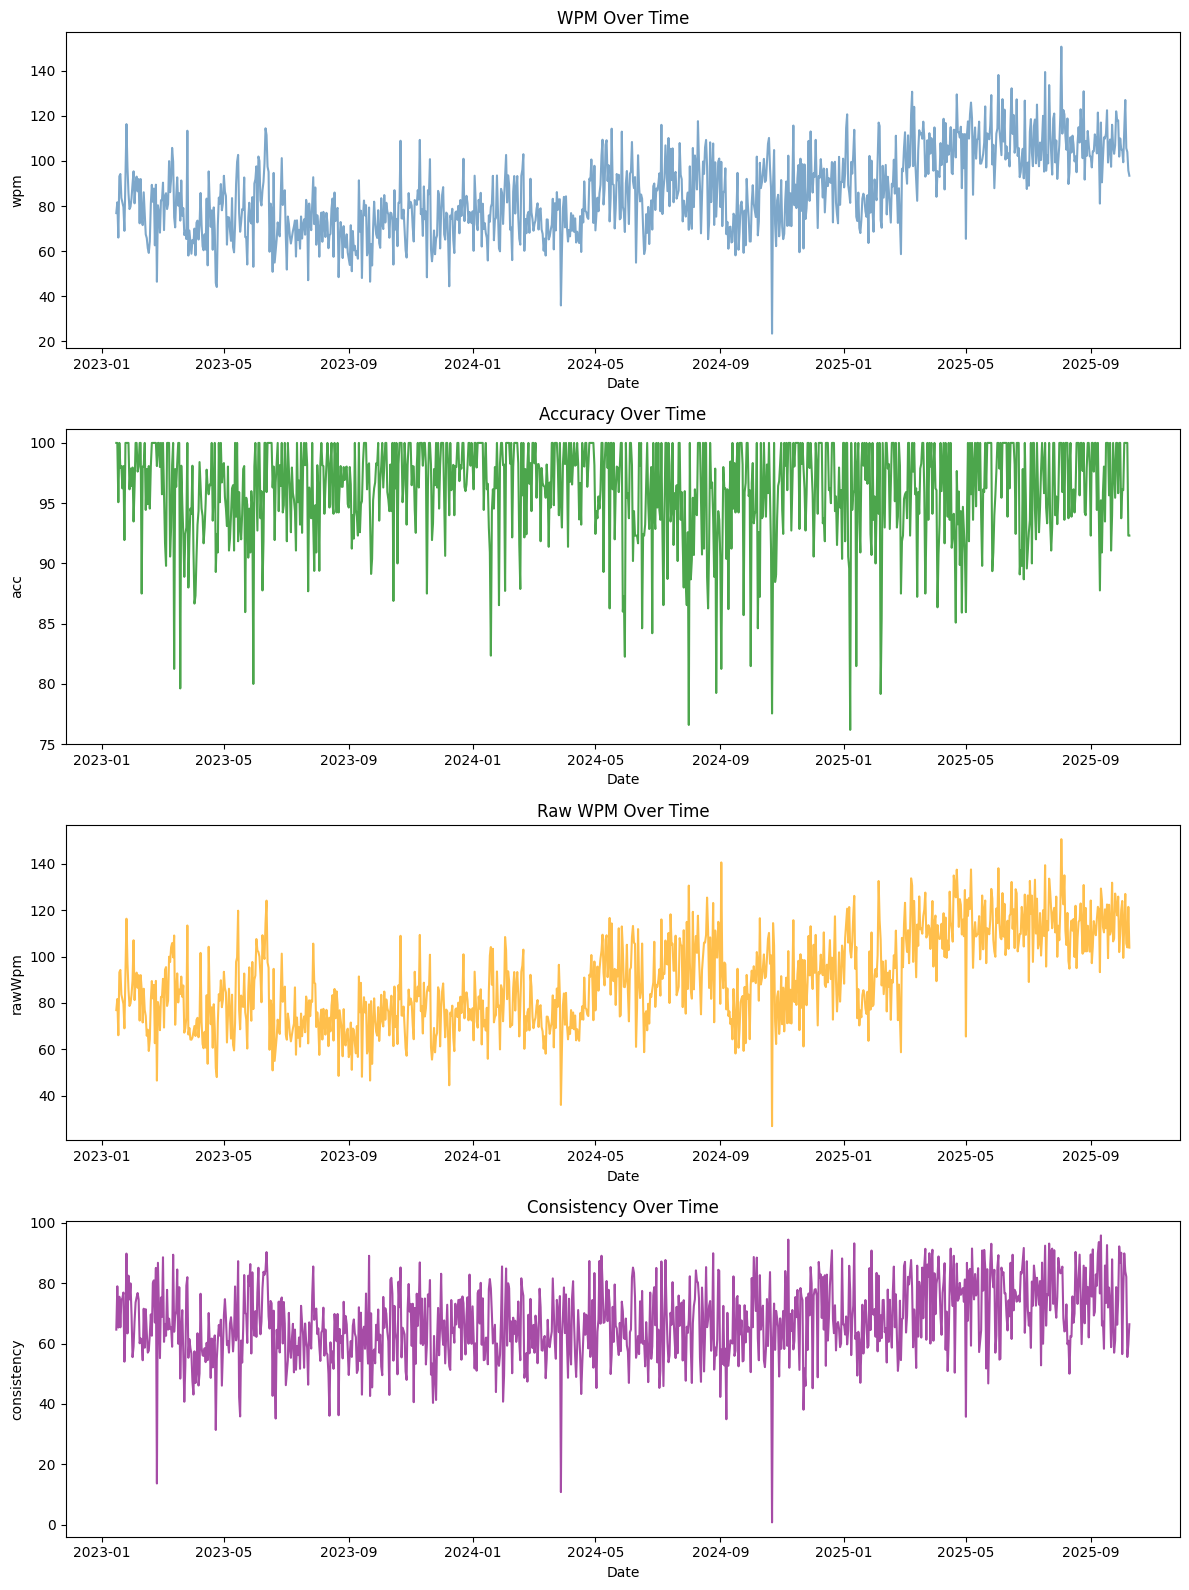

In [3]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date (oldest to newest)
df = df.sort_values('date').reset_index(drop=True)

# Plot all 4 metrics over time
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

metrics = ['wpm', 'acc', 'rawWpm', 'consistency']
colors = ['steelblue', 'green', 'orange', 'purple']
titles = ['WPM Over Time', 'Accuracy Over Time', 
          'Raw WPM Over Time', 'Consistency Over Time']

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    axes[i].plot(df['date'], df[metric], color=color, alpha=0.7)
    axes[i].set_title(title)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

In [4]:
# Create lag features — use last 7 days to predict next day
metrics = ['wpm', 'acc', 'rawWpm', 'consistency']

# Create lag features for each metric
for metric in metrics:
    for lag in range(1, 8):  # last 7 days
        df[f'{metric}_lag{lag}'] = df[metric].shift(lag)

# Create rolling averages (7 day and 30 day)
for metric in metrics:
    df[f'{metric}_rolling7'] = df[metric].shift(1).rolling(7).mean()
    df[f'{metric}_rolling30'] = df[metric].shift(1).rolling(30).mean()

# Drop rows with NaN (first 30 rows)
df_features = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df_features.shape)
print("Total features:", df_features.shape[1])

Shape after feature engineering: (969, 42)
Total features: 42


In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# Features and targets
feature_cols = [col for col in df_features.columns 
                if col not in ['date', 'days_ago', 'wpm', 'acc', 'rawWpm', 'consistency']]
target_cols = ['wpm', 'acc', 'rawWpm', 'consistency']

X = df_features[feature_cols]
y = df_features[target_cols]

# Split — first 800 days train, rest validation
X_train = X.iloc[:800]
X_val = X.iloc[800:]
y_train = y.iloc[:800]
y_val = y.iloc[800:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 800
Validation samples: 169
Number of features: 36


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# Build model — Gradient Boosting for each target
model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
)

# Train
model.fit(X_train, y_train)

# Validate
y_pred = model.predict(X_val)

# Evaluate each metric
print("Validation Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

Validation Results:
----------------------------------------
wpm: MAE = 12.2337
acc: MAE = 3.9179
rawWpm: MAE = 9.9700
consistency: MAE = 10.2376


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Try Random Forest with more trees
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

# Train
rf_model.fit(X_train, y_train)

# Validate
y_pred_rf = rf_model.predict(X_val)

# Evaluate
print("Random Forest Validation Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_rf[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

Random Forest Validation Results:
----------------------------------------
wpm: MAE = 11.0152
acc: MAE = 3.8034
rawWpm: MAE = 9.2834
consistency: MAE = 9.4123


In [8]:
# Add more recent lag features — last 3 days weighted more
for metric in metrics:
    # Recent trends
    df_features[f'{metric}_trend3'] = (
        df_features[f'{metric}_lag1'] - df_features[f'{metric}_lag3']
    )
    df_features[f'{metric}_trend7'] = (
        df_features[f'{metric}_lag1'] - df_features[f'{metric}_lag7']
    )
    # Recent momentum
    df_features[f'{metric}_momentum'] = (
        df_features[f'{metric}_lag1'] / df_features[f'{metric}_rolling7']
    )

# Update feature columns
feature_cols = [col for col in df_features.columns 
                if col not in ['date', 'days_ago', 'wpm', 'acc', 'rawWpm', 'consistency']]

X = df_features[feature_cols]
y = df_features[target_cols]

X_train = X.iloc[:800]
X_val = X.iloc[800:]
y_train = y.iloc[:800]
y_val = y.iloc[800:]

# Retrain Random Forest
rf_model2 = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

rf_model2.fit(X_train, y_train)
y_pred_rf2 = rf_model2.predict(X_val)

print("Improved Random Forest Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_rf2[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

Improved Random Forest Results:
----------------------------------------
wpm: MAE = 10.7483
acc: MAE = 3.7097
rawWpm: MAE = 9.1821
consistency: MAE = 9.4462


In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Use only last 30 days as training window
# This captures recent trend better than full history

# Add day number as feature (captures overall upward trend)
df_features['day_number'] = range(len(df_features))

# Add exponentially weighted moving average
for metric in metrics:
    df_features[f'{metric}_ewm7'] = df_features[metric].shift(1).ewm(span=7).mean()
    df_features[f'{metric}_ewm14'] = df_features[metric].shift(1).ewm(span=14).mean()
    df_features[f'{metric}_ewm30'] = df_features[metric].shift(1).ewm(span=30).mean()

# Update features
feature_cols = [col for col in df_features.columns 
                if col not in ['date', 'days_ago', 'wpm', 'acc', 'rawWpm', 'consistency']]

X = df_features[feature_cols]
y = df_features[target_cols]

X_train = X.iloc[:800]
X_val = X.iloc[800:]
y_train = y.iloc[:800]
y_val = y.iloc[800:]

# Train with Gradient Boosting
gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

print("Gradient Boosting + EWM Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_gb[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Drop NaN values created by EWM
df_features = df_features.dropna().reset_index(drop=True)

# Update features
feature_cols = [col for col in df_features.columns 
                if col not in ['date', 'days_ago', 'wpm', 'acc', 'rawWpm', 'consistency']]

X = df_features[feature_cols]
y = df_features[target_cols]

X_train = X.iloc[:800]
X_val = X.iloc[800:]
y_train = y.iloc[:800]
y_val = y.iloc[800:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Features:", X_train.shape[1])

# Train with Gradient Boosting
gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

print("\nGradient Boosting + EWM Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_gb[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

In [ ]:
print("Gradient Boosting + EWM Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_gb[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

In [ ]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

print("XGBoost Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_xgb[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

In [ ]:
# Ensemble — average predictions from RF and XGBoost
y_pred_ensemble = (y_pred_rf2 + y_pred_xgb) / 2

print("Ensemble (RF + XGBoost) Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val.iloc[:, i], y_pred_ensemble[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

In [ ]:
# Use minimum length to align both predictions
min_len = min(len(y_pred_rf2), len(y_pred_xgb))

y_pred_ensemble = (y_pred_rf2[:min_len] + y_pred_xgb[:min_len]) / 2
y_val_aligned = y_val.iloc[:min_len]

print("Ensemble (RF + XGBoost) Results:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    mae = mean_absolute_error(y_val_aligned.iloc[:, i], y_pred_ensemble[:, i])
    print(f"{metric}: MAE = {mae:.4f}")

In [ ]:
# Use RF + Trends model (rf_model2) for final prediction
# Get the last row of features — this represents day 998
last_row = X.iloc[[-1]]

# Predict day 999
final_prediction = rf_model2.predict(last_row)

print("Final Predictions for Day 999:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {final_prediction[0][i]:.4f}")

In [ ]:
# Retrain RF + Trends on current full feature set
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

rf_final = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

# Train on ALL available data (not just 800) for best prediction
rf_final.fit(X, y)

# Get last row for day 999 prediction
last_row = X.iloc[[-1]]

# Predict day 999
final_prediction = rf_final.predict(last_row)

print("Final Predictions for Day 999:")
print("-" * 40)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {final_prediction[0][i]:.4f}")

In [ ]:
# Create predictions dataframe
predictions = pd.DataFrame({
    'wpm': [final_prediction[0][0]],
    'acc': [final_prediction[0][1]],
    'rawWpm': [final_prediction[0][2]],
    'consistency': [final_prediction[0][3]]
})

print("Predictions:")
print(predictions)

# Save to CSV
predictions.to_csv('Round3_Predictions_ArpitaRathwa.csv', index=False)
print("\nPredictions saved successfully!")